In [2]:
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import json

In [2]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp')

data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [3]:
file_list

[PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4520.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4838.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3789.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_4444.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_811.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3425.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_1808.json'),
 PosixPath('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_temp/1_movable/env_config_3859.json'),
 PosixPath('/common/users/dm1487/ktamp_da

In [4]:
for idx in range(30):
    with open(file_list[idx], 'r') as f:
        data = json.load(f)
        print(data['xml_path'])
        print("from file", data['reachability_radius'])
        goal_success = np.array(data['goal_success'])
        
        radius_step = 0.01
        max_radius = 1.6 + radius_step
        reachability_radius = 1.6

        for radius in np.arange(radius_step, max_radius, radius_step):
            goal_success_radius = goal_success[goal_success[:, 0]**2 + goal_success[:, 1]**2 <= radius**2]
            if len(goal_success_radius) == 0:
                continue
            if np.sum(goal_success_radius[:, 2]) / len(goal_success_radius) < 1.0:
                
                break
            reachability_radius = radius

    print("reachability radius", reachability_radius)

        # plt.scatter(goal_success_radius[:, 0], goal_success_radius[:, 1], c=goal_success_radius[:, 2], cmap='RdBu')

        # break
    
    # plt.xlim(-1.6, 1.6)
    # plt.ylim(-1.6, 1.6)
    # plt.show()


    # plt.scatter(goal_success[:, 0], goal_success[:, 1], c=goal_success[:, 2], cmap='RdBu')
    # # goal_success = np.array(data['goal_success'])[:, -1].reshape(17, 17, 1)
    # # plt.imshow(goal_success, cmap='gray')
    # plt.show()
    # plt.colorbar()

cylinder_envs/1_movable/env_config_4520.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_4838.xml
from file 1.800000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3789.xml
from file 1.5500000000000007
reachability radius 1.59
cylinder_envs/1_movable/env_config_4444.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_811.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3425.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_1808.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3859.xml
from file 1.4500000000000006
reachability radius 1.46
cylinder_envs/1_movable/env_config_1474.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_3541.xml
from file 2.000000000000001
reachability radius 1.6
cylinder_envs/1_movable/env_config_97

In [51]:
aggregated_data_path = Path('/common/users/dm1487/ktamp_data_rename/cylinder_envs_large_aggregate_new_temp_1')
data_path = aggregated_data_path # / '1_mixed'
file_list = list(data_path.glob('*/*.json'))

In [52]:
with open(file_list[0], 'r') as f:
    data = json.load(f)

(40, 40)
(40, 40)
(40, 40)
(40, 40)


Text(0.5, 1.0, 'Robot Mask')

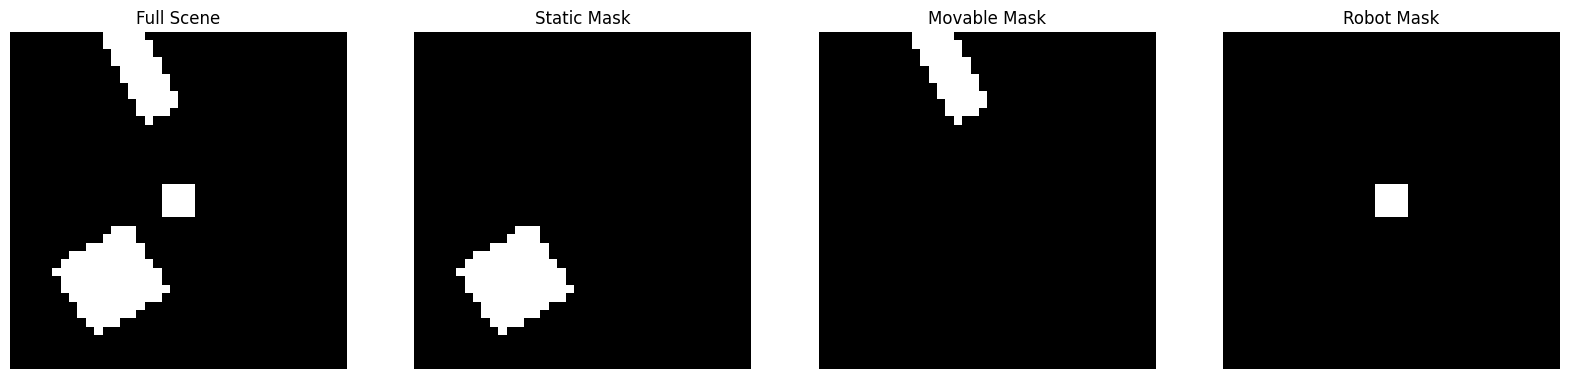

In [55]:
full_scene = np.array(data['scene_images']['full_scene'])
static_mask = np.array(data['scene_images']['static_mask'])
movable_mask = np.array(data['scene_images']['movable_mask'])
robot_mask = np.array(data['scene_images']['robot_mask'])

print(full_scene.shape)
print(static_mask.shape)
print(movable_mask.shape)
print(robot_mask.shape)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(full_scene, cmap='gray')
axs[0].axis('off')
axs[0].set_title('Full Scene')

axs[1].imshow(static_mask, cmap='gray')
axs[1].axis('off')
axs[1].set_title('Static Mask')

axs[2].imshow(movable_mask, cmap='gray')
axs[2].axis('off')
axs[2].set_title('Movable Mask')

axs[3].imshow(robot_mask, cmap='gray')
axs[3].axis('off')
axs[3].set_title('Robot Mask')

[[-1.49279, 1.099079, 1.0, 419.0], [-1.562761, 1.175298, 1.0, 431.0]]